# 🌧️ Probability Theory — Everyday Examples

Learning probability through situations you actually encounter: traffic, rain, late buses, and dodgy weather forecasts.

**All you need:** `matplotlib` and basic Python


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("Ready ✓")


Ready ✓


---
## 1. Probability Space

A probability space just means: **list every possible outcome, and assign each a probability that sums to 1.**

### Scenario: Your morning commute
Every morning one of four things happens:


In [2]:
# The sample space — every possible outcome and its probability
commute_outcomes = {
    "on time":          0.50,   # 50% of mornings, fine
    "slightly late":    0.25,   # 25%, a bit delayed
    "very late":        0.15,   # 15%, bad day
    "working from home":0.10,   # 10%, skip the commute entirely
}

# The probabilities must sum to 1 — that's the key rule
total = sum(commute_outcomes.values())
print("Outcome              Probability")
print("-" * 35)
for outcome, prob in commute_outcomes.items():
    bar = "█" * int(prob * 40)
    print(f"{outcome:<22} {prob:.0%}  {bar}")
print("-" * 35)
print(f"Total                {total:.0%}  ← must equal 100%")


Outcome              Probability
-----------------------------------
on time                50%  ████████████████████
slightly late          25%  ██████████
very late              15%  ██████
working from home      10%  ████
-----------------------------------
Total                100%  ← must equal 100%


P(late at all)    = 25% + 15% = 40%
P(go to office)   = 1 - P(WFH) = 90%
P(on time or WFH) = 60%


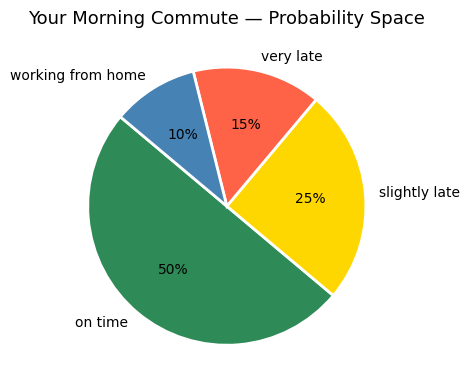

In [3]:
# We can combine outcomes into EVENTS
# An "event" is just a question we ask about the outcome

P = commute_outcomes   # shorthand

P_late = P["slightly late"] + P["very late"]
P_in_office = P["on time"] + P["slightly late"] + P["very late"]

print(f"P(late at all)    = {P['slightly late']:.0%} + {P['very late']:.0%} = {P_late:.0%}")
print(f"P(go to office)   = 1 - P(WFH) = {P_in_office:.0%}")
print(f"P(on time or WFH) = {P['on time'] + P['working from home']:.0%}")

# Plot
fig, ax = plt.subplots()
colors = ['seagreen', 'gold', 'tomato', 'steelblue']
wedges, texts, autotexts = ax.pie(
    commute_outcomes.values(),
    labels=commute_outcomes.keys(),
    colors=colors, autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title("Your Morning Commute — Probability Space", fontsize=13)
plt.tight_layout()
plt.show()


---
## 2. Conditional Probability

**"Given that I already know X, what's the probability of Y?"**

### Scenario: Being late given it's raining

On a normal day you have a 20% chance of being late.  
But if it's raining, that jumps to 60%.

> P(late | raining) = 0.60  
> P(late | not raining) = 0.20

The vertical bar **|** just means *"given that"*.


In [4]:
# Conditional probabilities — "given that" tables
P_rain = 0.30   # it rains 30% of mornings in this city

# P(late | weather)
P_late_given_rain    = 0.60
P_late_given_no_rain = 0.20

print("Conditional probability table:")
print(f"  P(late | raining)     = {P_late_given_rain:.0%}")
print(f"  P(late | not raining) = {P_late_given_no_rain:.0%}")
print()
print("Reading this: on rainy days, 3× more likely to be late.")


Conditional probability table:
  P(late | raining)     = 60%
  P(late | not raining) = 20%

Reading this: on rainy days, 3× more likely to be late.


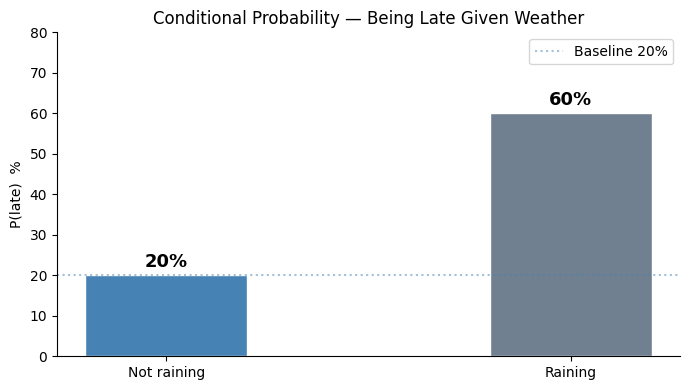

In [5]:
# Visualise: how rain changes the probability of being late
scenarios = ['Not raining', 'Raining']
probs     = [P_late_given_no_rain, P_late_given_rain]
colors    = ['steelblue', 'slategrey']

fig, ax = plt.subplots()
bars = ax.bar(scenarios, [p*100 for p in probs], color=colors, width=0.4, edgecolor='white')
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{p:.0%}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('P(late)  %')
ax.set_title('Conditional Probability — Being Late Given Weather')
ax.set_ylim(0, 80)
ax.axhline(20, color='steelblue', linestyle=':', alpha=0.5, label='Baseline 20%')
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Chain Rule

The chain rule answers: **"what's the chance that TWO things both happen?"**

$$P(A \text{ and } B) = P(A) \times P(B \mid A)$$

### Scenario: Raining AND late

- P(raining) = 30%  
- P(late | raining) = 60%  
- P(raining AND late) = ?


In [6]:
# Chain rule: P(rain AND late) = P(rain) × P(late | rain)
P_rain_and_late = P_rain * P_late_given_rain

print("Chain Rule:")
print(f"  P(rain)            = {P_rain:.0%}")
print(f"  P(late | rain)     = {P_late_given_rain:.0%}")
print(f"  ─────────────────────────────────")
print(f"  P(rain AND late)   = {P_rain:.0%} × {P_late_given_rain:.0%} = {P_rain_and_late:.0%}")
print()
print("In other words: on any given morning, there's an 18% chance")
print("it's raining AND you're late.")


Chain Rule:
  P(rain)            = 30%
  P(late | rain)     = 60%
  ─────────────────────────────────
  P(rain AND late)   = 30% × 60% = 18%

In other words: on any given morning, there's an 18% chance
it's raining AND you're late.


Extended Chain Rule: Rain → Traffic → Late

  P(rain)                         = 30%
  P(traffic | rain)               = 70%
  P(late | rain & traffic)        = 80%
  ────────────────────────────────────────────
  P(rain AND traffic AND late)    = 30% × 70% × 80% = 16.8%

So about 1 in 6 mornings tick all three boxes.


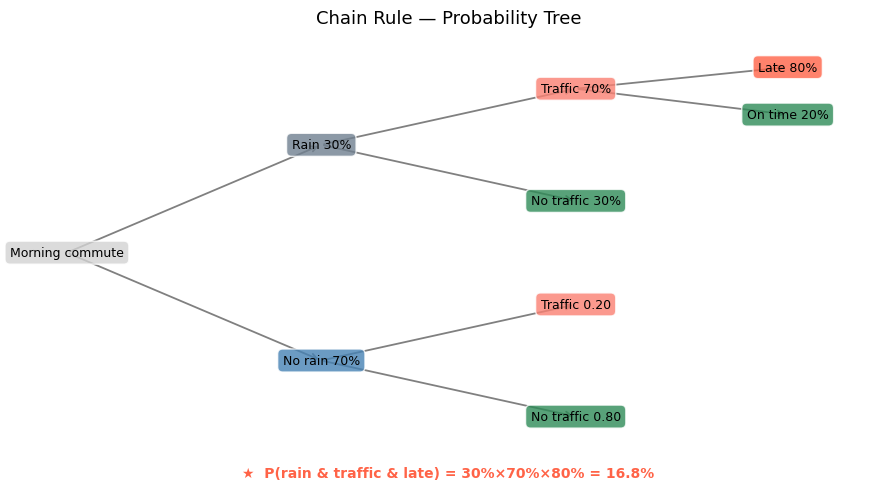

In [9]:
# Extend: three things — raining AND traffic AND late
P_traffic_given_rain = 0.70   # traffic is much worse when it rains
P_late_given_rain_and_traffic = 0.80

P_all_three = P_rain * P_traffic_given_rain * P_late_given_rain_and_traffic

print("Extended Chain Rule: Rain → Traffic → Late")
print()
print(f"  P(rain)                         = {P_rain:.0%}")
print(f"  P(traffic | rain)               = {P_traffic_given_rain:.0%}")
print(f"  P(late | rain & traffic)        = {P_late_given_rain_and_traffic:.0%}")
print(f"  ────────────────────────────────────────────")
print(f"  P(rain AND traffic AND late)    = {P_rain:.0%} × {P_traffic_given_rain:.0%} × {P_late_given_rain_and_traffic:.0%} = {P_all_three:.1%}")
print()
print(f"So about 1 in 6 mornings tick all three boxes.")

# Visualise as a tree
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')

# Nodes: (x, y, label, color)
nodes = [
    (0.05, 0.5,  "Morning commute",            'lightgrey'),
    (0.35, 0.75, f"Rain {P_rain:.0%}",          'slategrey'),
    (0.35, 0.25, f"No rain {1-P_rain:.0%}",     'steelblue'),
    (0.65, 0.88, f"Traffic {P_traffic_given_rain:.0%}", 'salmon'),
    (0.65, 0.62, f"No traffic {1-P_traffic_given_rain:.0%}", 'seagreen'),
    (0.65, 0.38, f"Traffic 0.20",               'salmon'),
    (0.65, 0.12, f"No traffic 0.80",            'seagreen'),
    (0.90, 0.93, f"Late {P_late_given_rain_and_traffic:.0%}", 'tomato'),
    (0.90, 0.82, f"On time {1-P_late_given_rain_and_traffic:.0%}", 'seagreen'),
]

edges = [
    (0.05,0.5, 0.35,0.75), (0.05,0.5, 0.35,0.25),
    (0.35,0.75, 0.65,0.88), (0.35,0.75, 0.65,0.62),
    (0.35,0.25, 0.65,0.38), (0.35,0.25, 0.65,0.12),
    (0.65,0.88, 0.90,0.93), (0.65,0.88, 0.90,0.82),
]
for x1,y1,x2,y2 in edges:
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='grey', lw=1.3),
                xycoords='axes fraction', textcoords='axes fraction')

for x,y,label,color in nodes:
    ax.text(x, y, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.4', fc=color, ec='white', alpha=0.8))

# Highlight the path
ax.text(0.50, -0.02, f"★  P(rain & traffic & late) = {P_rain:.0%}×{P_traffic_given_rain:.0%}×{P_late_given_rain_and_traffic:.0%} = {P_all_three:.1%}",
        transform=ax.transAxes, ha='center', fontsize=10, color='tomato', fontweight='bold')
ax.set_title("Chain Rule — Probability Tree", fontsize=13, pad=10)
plt.tight_layout()
plt.show()


---
## 4. Bayes' Theorem

Bayes' theorem lets us reason **backwards**: given that something happened, what probably caused it?

$$P(\text{cause} \mid \text{effect}) = \frac{P(\text{effect} \mid \text{cause}) \times P(\text{cause})}{P(\text{effect})}$$

### Scenario: You're late — was it raining?

You just arrived late to work. Your colleague asks: *"Was it raining?"*  
You didn't check before leaving. What's the probability it was raining, given you're late?


In [10]:
# We know:
#   P(rain)               = 30%
#   P(late | rain)        = 60%
#   P(late | no rain)     = 20%

# Step 1: total probability of being late (on any morning)
P_no_rain = 1 - P_rain
P_late = (P_late_given_rain * P_rain) + (P_late_given_no_rain * P_no_rain)

print("Step 1 — How often are you late overall?")
print(f"  P(late) = P(late|rain)×P(rain) + P(late|no rain)×P(no rain)")
print(f"          = {P_late_given_rain:.0%}×{P_rain:.0%} + {P_late_given_no_rain:.0%}×{P_no_rain:.0%}")
print(f"          = {P_late_given_rain*P_rain:.0%} + {P_late_given_no_rain*P_no_rain:.0%}")
print(f"          = {P_late:.0%}")


Step 1 — How often are you late overall?
  P(late) = P(late|rain)×P(rain) + P(late|no rain)×P(no rain)
          = 60%×30% + 20%×70%
          = 18% + 14%
          = 32%


In [11]:
# Step 2: Apply Bayes — P(rain | late)
P_rain_given_late = (P_late_given_rain * P_rain) / P_late

print("Step 2 — Bayes' Theorem:")
print(f"  P(rain | late) = P(late | rain) × P(rain) / P(late)")
print(f"                 = {P_late_given_rain:.0%} × {P_rain:.0%} / {P_late:.0%}")
print(f"                 = {P_rain_given_late:.1%}")
print()
print(f"So if you arrive late, there's a {P_rain_given_late:.0%} chance it was raining.")
print(f"(Before knowing you were late, the chance of rain was only {P_rain:.0%}.)")
print()
print("Being late is evidence of rain — it raised our estimate from 30% to 56%.")


Step 2 — Bayes' Theorem:
  P(rain | late) = P(late | rain) × P(rain) / P(late)
                 = 60% × 30% / 32%
                 = 56.3%

So if you arrive late, there's a 56% chance it was raining.
(Before knowing you were late, the chance of rain was only 30%.)

Being late is evidence of rain — it raised our estimate from 30% to 56%.


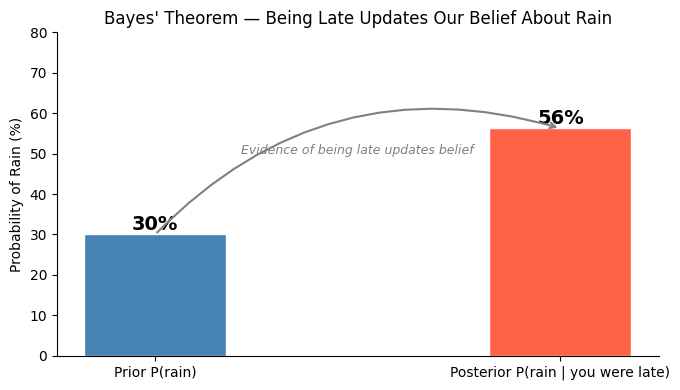

In [14]:
# Visualise: prior vs posterior
fig, ax = plt.subplots(figsize=(7, 4))

categories = ['Prior P(rain)', 'Posterior P(rain | you were late)']
values     = [P_rain, P_rain_given_late]
colors     = ['steelblue', 'tomato']

bars = ax.bar(categories, [v*100 for v in values], color=colors, width=0.35, edgecolor='white')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0%}', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Probability of Rain (%)')
ax.set_title("Bayes' Theorem — Being Late Updates Our Belief About Rain")
ax.set_ylim(0, 80)
ax.annotate('', xy=(1, P_rain_given_late*100), xytext=(0, P_rain*100),
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.5,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(0.5, 50, 'Evidence of being late updates belief', ha='center', fontsize=9, color='grey', style='italic')
plt.tight_layout()
plt.show()


---
## 5. Random Variables

A **random variable** is just a number that depends on something random.

Instead of saying "you might be on time, slightly late, or very late", we assign numbers:
- X = 0 minutes late → on time  
- X = 15 minutes late → slightly late  
- X = 45 minutes late → very late  

Then we can calculate things like the **average lateness**.


In [15]:
# Random variable: minutes late on a rainy day
# X = minutes late, with probabilities given rain

# On a RAINY day:
rain_outcomes = {
    0:  0.40,   # 40% chance on time (0 min late)
    10: 0.25,   # 25% chance 10 mins late
    20: 0.20,   # 20% chance 20 mins late
    40: 0.10,   # 10% chance 40 mins late
    60: 0.05,   # 5%  chance 60 mins late
}

# Expected value = weighted average = "how late on average?"
E_rain = sum(x * p for x, p in rain_outcomes.items())

print("Rainy day — distribution of lateness:")
print(f"{'Minutes late':>14}  {'Probability':>12}  {'Contribution to mean':>22}")
print("-" * 52)
for x, p in rain_outcomes.items():
    print(f"{x:>14}  {p:>12.0%}  {x*p:>22.1f} min")
print("-" * 52)
print(f"{'Expected value E[X]':>28} = {E_rain:.1f} minutes late on average")


Rainy day — distribution of lateness:
  Minutes late   Probability    Contribution to mean
----------------------------------------------------
             0           40%                     0.0 min
            10           25%                     2.5 min
            20           20%                     4.0 min
            40           10%                     4.0 min
            60            5%                     3.0 min
----------------------------------------------------
         Expected value E[X] = 13.5 minutes late on average


Expected lateness on a DRY day:   4.8 minutes
Expected lateness on a RAINY day: 13.5 minutes
Rain costs you an extra 8.7 minutes on average.


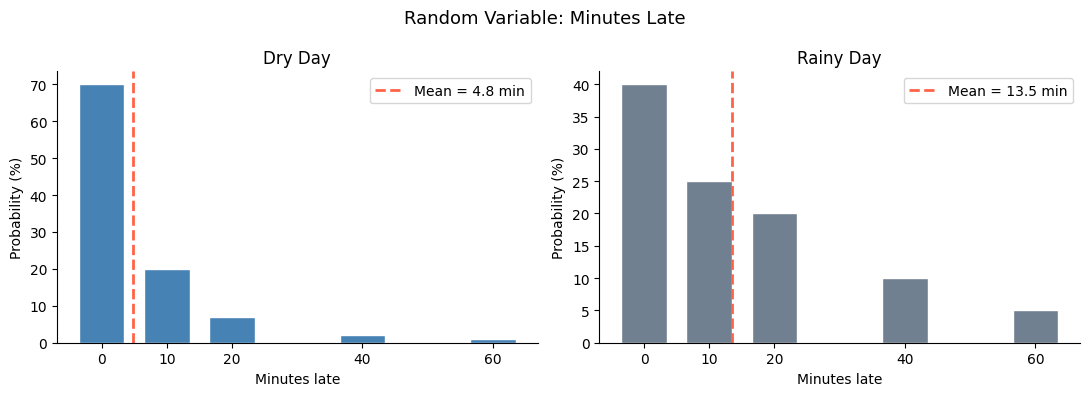

In [16]:
# Compare rainy vs dry day
dry_outcomes = {
    0:  0.70,
    10: 0.20,
    20: 0.07,
    40: 0.02,
    60: 0.01,
}
E_dry = sum(x * p for x, p in dry_outcomes.items())

print(f"Expected lateness on a DRY day:   {E_dry:.1f} minutes")
print(f"Expected lateness on a RAINY day: {E_rain:.1f} minutes")
print(f"Rain costs you an extra {E_rain - E_dry:.1f} minutes on average.")

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, outcomes, mean, title, color in [
    (axes[0], dry_outcomes,  E_dry,  'Dry Day',   'steelblue'),
    (axes[1], rain_outcomes, E_rain, 'Rainy Day', 'slategrey'),
]:
    xs = list(outcomes.keys())
    ps = [p*100 for p in outcomes.values()]
    ax.bar(xs, ps, color=color, width=7, edgecolor='white')
    ax.axvline(mean, color='tomato', linestyle='--', lw=2, label=f'Mean = {mean:.1f} min')
    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('Minutes late')
    ax.set_ylabel('Probability (%)')
    ax.legend()
    ax.set_xticks(xs)

plt.suptitle('Random Variable: Minutes Late', fontsize=13)
plt.tight_layout()
plt.show()


---
## 6. Variance

The **expected value** tells you the average. But it doesn't tell you how *predictable* things are.

**Variance** measures how spread out the outcomes are around the mean.  
A high variance means "very unpredictable". A low variance means "fairly reliable".

$$\text{Var}(X) = \text{average of } (X - \text{mean})^2$$

### Scenario: Two bus routes — same average, different reliability


In [17]:
# Two bus routes both average 5 minutes late,
# but Route B is far more unpredictable

route_A = {  # Reliable bus: usually close to 5 mins
    3: 0.20,
    4: 0.25,
    5: 0.30,
    6: 0.15,
    7: 0.10,
}

route_B = {  # Chaotic bus: sometimes early, sometimes very late
    0:  0.15,
    2:  0.15,
    5:  0.20,
    8:  0.25,
    12: 0.25,
}

def expected_value(dist):
    return sum(x * p for x, p in dist.items())

def variance(dist):
    mu = expected_value(dist)
    return sum((x - mu)**2 * p for x, p in dist.items())

E_A, Var_A = expected_value(route_A), variance(route_A)
E_B, Var_B = expected_value(route_B), variance(route_B)

print(f"Route A — Reliable Bus")
print(f"  Mean lateness = {E_A:.1f} min,  Variance = {Var_A:.2f},  Std dev = {Var_A**0.5:.2f} min")
print()
print(f"Route B — Chaotic Bus")
print(f"  Mean lateness = {E_B:.1f} min,  Variance = {Var_B:.2f},  Std dev = {Var_B**0.5:.2f} min")
print()
print("Same average, but Route B is far more unpredictable.")
print(f"Standard deviation tells you: Route B swings ±{Var_B**0.5:.1f} min vs Route A's ±{Var_A**0.5:.1f} min.")


Route A — Reliable Bus
  Mean lateness = 4.7 min,  Variance = 1.51,  Std dev = 1.23 min

Route B — Chaotic Bus
  Mean lateness = 6.3 min,  Variance = 17.91,  Std dev = 4.23 min

Same average, but Route B is far more unpredictable.
Standard deviation tells you: Route B swings ±4.2 min vs Route A's ±1.2 min.


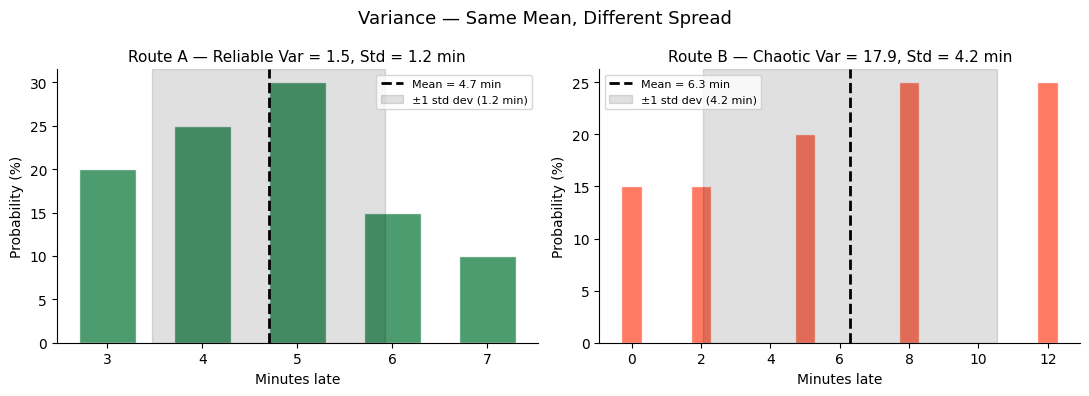

In [21]:
# Visualise both distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, route, E, Var, title, color in [
    (axes[0], route_A, E_A, Var_A, 'Route A — Reliable', 'seagreen'),
    (axes[1], route_B, E_B, Var_B, 'Route B — Chaotic',  'tomato'),]:
    xs = list(route.keys())
    ps = [p*100 for p in route.values()]
    ax.bar(xs, ps, color=color, width=0.6, edgecolor='white', alpha=0.85)
    ax.axvline(E, color='black', linestyle='--', lw=2, label=f'Mean = {E:.1f} min')
    # Shade ±1 std dev
    sd = Var**0.5
    ax.axvspan(E - sd, E + sd, alpha=0.12, color='black', label=f'±1 std dev ({sd:.1f} min)')
    ax.set_title(f'{title} Var = {Var:.1f}, Std = {sd:.1f} min', fontsize=11)
    ax.set_xlabel('Minutes late'); ax.set_ylabel('Probability (%)')
    ax.legend(fontsize=8)

plt.suptitle('Variance — Same Mean, Different Spread', fontsize=13)
plt.tight_layout()
plt.show()


In [22]:
# Practical meaning of variance: how often will you miss a meeting?
# Suppose you have a meeting and can afford to be at most 6 minutes late.

threshold = 6

def P_miss_meeting(route, threshold):
    return sum(p for x, p in route.items() if x > threshold)

miss_A = P_miss_meeting(route_A, threshold)
miss_B = P_miss_meeting(route_B, threshold)

print(f"If you can only afford to be ≤{threshold} minutes late:")
print()
print(f"  Route A (low variance):  P(miss meeting) = {miss_A:.0%}")
print(f"  Route B (high variance): P(miss meeting) = {miss_B:.0%}")
print()
print("High variance is costly even when the average is the same.")
print("This is why variance matters — not just the mean.")


If you can only afford to be ≤6 minutes late:

  Route A (low variance):  P(miss meeting) = 10%
  Route B (high variance): P(miss meeting) = 50%

High variance is costly even when the average is the same.
This is why variance matters — not just the mean.


---
## Summary

| Concept | Our Example | Key Idea |
|---|---|---|
| **Probability Space** | Morning commute outcomes | List all outcomes; probabilities sum to 1 |
| **Conditional Probability** | P(late \| raining) | How does knowing one thing change another? |
| **Chain Rule** | P(rain AND traffic AND late) | Multiply step by step along a chain |
| **Bayes' Theorem** | P(raining \| you were late) | Reason backwards from effect to cause |
| **Random Variable** | Minutes late = a number | Turn outcomes into numbers to do maths |
| **Variance** | Reliable vs chaotic bus | How spread out / unpredictable are the outcomes? |
